# Bus Data
### Project PAD
### Viktória Kovácsová

# Introduction

In this analysis, we used our own observations of passengers on the route from Nové Zámky to Nitra. The data was collected on Wednesday morning, 19.11., during the service departing at 7:55. The dataset provides information about individual passengers on the bus, mapping demographic data, travel parameters, and passenger behavior.

The most important variables used in the analysis are:
- `has_discount_ticket` passenger ticket type (dichotomous: Yes = discounted / No = full price)
- `origin_stop` boarding stop (nominal: Nové Zámky, Šurany, Komjatice, Veľký Kýr, Branč, Ivanka pri Nitre, Nitra)
- `destination` alighting stop (nominal: Šurany, Komjatice, Veľký Kýr, Branč, Ivanka pri Nitre, Nitra)
- `age_group` age category (ordinal text: Child, Teen, Young_adult, Adult, Senior)
- `device_engagement` level of phone usage (ordinal numeric: 1 = does not hold phone during the entire ride → 5 = constantly uses phone)
- `minutes_on_bus` time spent on the bus in minutes (interval)
- `travelled_distance_km` distance travelled in km (ratio, calculated)
- `bag_weight_kg` approximate luggage weight in kg (ratio)

The first step is to import the necessary libraries for data analysis, as well as statistical functions for testing normality, equality of variances, hypothesis testing, and correlation.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import shapiro, levene, ttest_ind, mannwhitneyu, spearmanr, kruskal, chi2_contingency

Next, we import the dataset:

In [3]:
df = pd.read_excel('NOVY_bus_data.xlsx')

To get an overview of the dataset, we display the first rows:

In [4]:
df.head()

,Záznam,has_discount_ticket,origin_stop,destination,age_group,device_engagement,minutes_on_bus,travelled_distance_km,bag_weight_kg
0,1,Yes,Nové Zámky,Nitra,Young_adult,4,57,39,4.50
1,2,Yes,Nové Zámky,Nitra,Teen,5,57,39,3.80
2,3,Yes,Nové Zámky,Nitra,Young_adult,2,57,39,4.75
3,4,No,Nové Zámky,Nitra,Adult,4,57,39,0.50
4,5,Yes,Nové Zámky,Nitra,Senior,1,57,39,0.75


## Exploratory Analysis – Overview

In this section, we examine the basic characteristics of the dataset and the distribution of individual variables in order to draw visual conclusions and formulate testable hypotheses.

We begin with summary statistics for key numerical variables to understand their central tendency and variability.

In [5]:
print(df[['minutes_on_bus', 'travelled_distance_km', 'bag_weight_kg', 'device_engagement']].describe().round(2))

       minutes_on_bus  travelled_distance_km  bag_weight_kg  device_engagement
count           32.00                  32.00          32.00              32.00
mean            36.03                  19.81           1.57               2.38
std             15.52                  11.40           1.45               1.50
min              6.00                   3.00           0.00               1.00
25%             29.00                  13.00           0.50               1.00
50%             37.00                  18.00           0.92               2.00
75%             42.00                  20.00           2.86               4.00
max             57.00                  39.00           4.75               5.00


Conclusion: The high standard deviation for minutes_on_bus (15.52) and travelled_distance_km (11.40) indicates large differences in trip length between passengers (6 to 57 minutes). The variability is significant, meaning some passengers travel much shorter or longer than average.

To check skewness and potential outliers, we examine the distribution of `minutes_on_bus` using a histogram and boxplot.

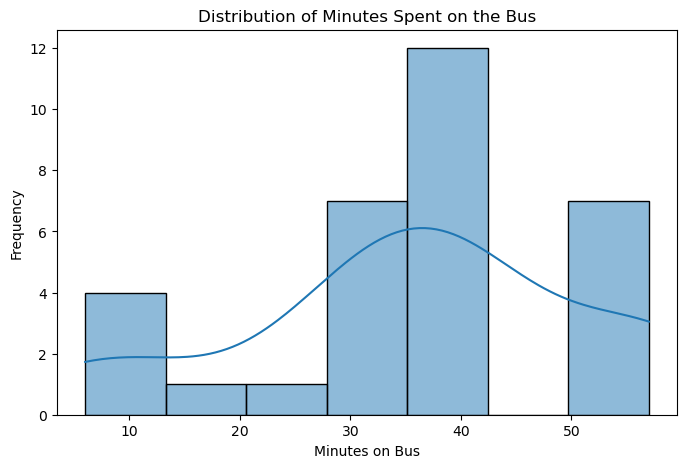

In [6]:
plt.figure(figsize=(8, 5))
sns.histplot(df['minutes_on_bus'], kde=True)
plt.title('Distribution of Minutes Spent on the Bus')
plt.xlabel('Minutes on Bus')
plt.ylabel('Frequency')
plt.show()

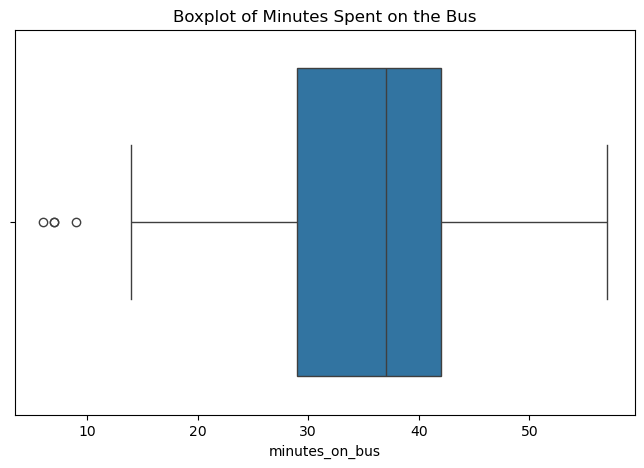

In [7]:
plt.figure(figsize=(8, 5))
sns.boxplot(x=df['minutes_on_bus']) 
plt.title('Boxplot of Minutes Spent on the Bus') 
plt.show()

Conclusion: The histogram and boxplot show that time spent on the bus ranges from 6 to 57 minutes. The average time is approximately 36 minutes, with some passengers travelling considerably shorter or longer than the average.

In the Inferential Analysis (Test 1) we will formally test whether there is a difference in trip length between passengers with and without a discount.

We also examine passenger distribution by age group (`age_group`) and its relationship with discount usage (`has_discount_ticket`).

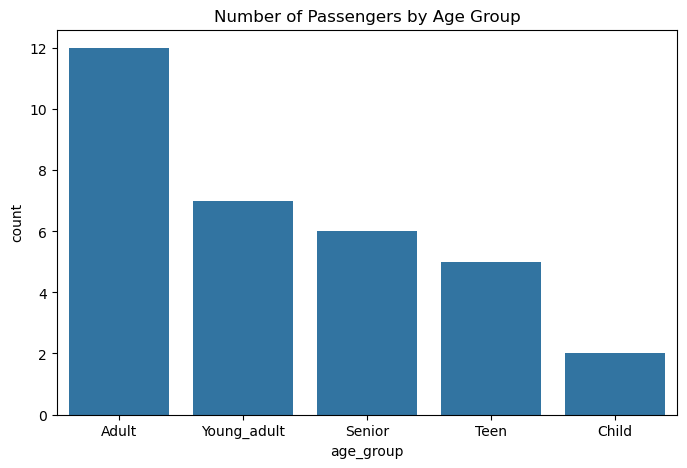

In [8]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x="age_group", order=df["age_group"].value_counts().index)
plt.title("Number of Passengers by Age Group")
plt.show()

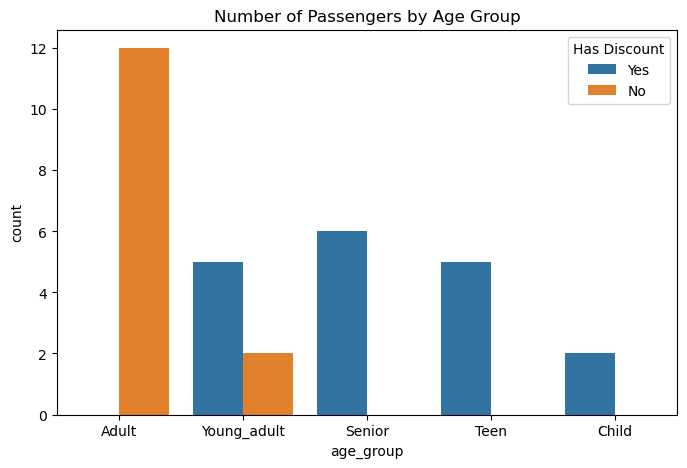

In [9]:
age_counts = df['age_group'].value_counts().index

plt.figure(figsize=(8, 5))
sns.countplot(data=df, x="age_group", hue="has_discount_ticket", order=age_counts)
plt.title("Number of Passengers by Age Group")
plt.legend(title='Has Discount', loc='upper right')
plt.show()

Conclusion: The Adult group is the largest (12 people). Discounts are most common in Teen, Child, and Senior categories. In the Young_adult group, we observe a mix, suggesting the presence of students.

Based on these findings, we transform the data and create a binary variable `is_student` for filtering and testing specific hypotheses about student behavior (e.g., relationship to luggage and boarding location).

In [10]:
df['is_student'] = np.where(
(df['age_group'] == 'Child')  |
(df['age_group'] == 'Teen') |
((df['age_group'] == 'Young_adult') & (df['has_discount_ticket'] == 'Yes')),
True,
False
)

print("\nDistribution of the new variable is_student:")
print(df['is_student'].value_counts())


Distribution of the new variable is_student:
is_student
False    20
True     12
Name: count, dtype: int64


With the new variable, we explore the student's relationship to physical load (`bag_weight_kg`) and the geographic concentration of students (`origin_stop`).
The boxplot allows us to visually compare medians and variability of luggage weight between students and non-students, providing visual evidence for the upcoming inferential test.

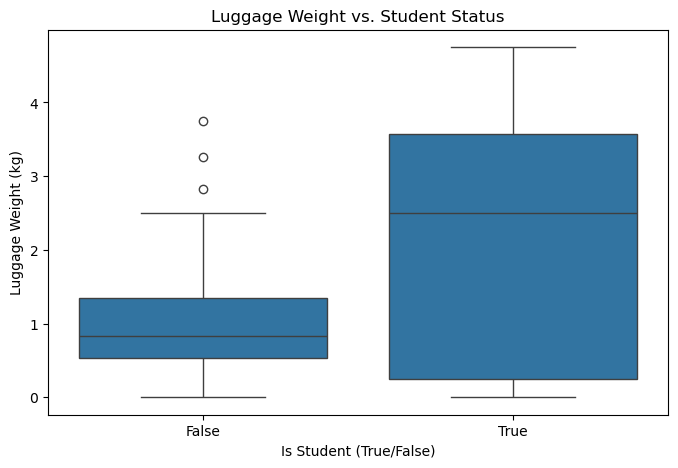

In [11]:
plt.figure(figsize=(8, 5))
sns.boxplot(x='is_student', y='bag_weight_kg', data=df)
plt.title('Luggage Weight vs. Student Status')
plt.xlabel('Is Student (True/False)')
plt.ylabel('Luggage Weight (kg)')
plt.show()

From the boxplot we can see that students tend to carry heavier luggage than non-students. To verify whether this difference is statistically significant, we will perform a Mann-Whitney U test, which compares medians between groups.

What's next: We will check whether travel distance is related to luggage weight (Test 2).

Examining the non-homogeneity of passengers at different stops. If age groups are non-homogeneously distributed, this suggests that a dependency exists between the boarding stop and the demographic structure.

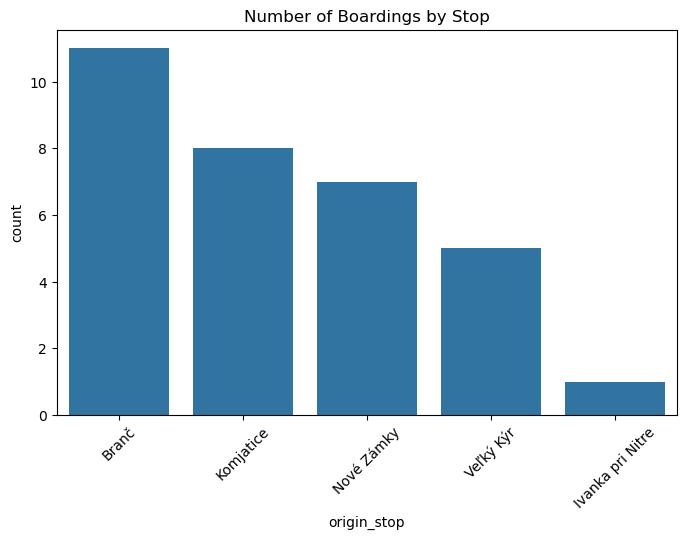

In [12]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x="origin_stop",
              order=df["origin_stop"].value_counts().index)
plt.xticks(rotation=45)
plt.title("Number of Boardings by Stop")
plt.show()

In [13]:
pivot = pd.pivot_table(
    df,index="origin_stop", columns="age_group", values="minutes_on_bus", aggfunc="count", margins=True).fillna(0)
pivot

age_group,Adult,Child,Senior,Teen,Young_adult,All
origin_stop,,,,,,
Branč,6.0,0.0,5.0,0.0,0.0,11
Ivanka pri Nitre,1.0,0.0,0.0,0.0,0.0,1
Komjatice,2.0,2.0,0.0,3.0,1.0,8
Nové Zámky,2.0,0.0,1.0,1.0,3.0,7
Veľký Kýr,1.0,0.0,0.0,1.0,3.0,5
All,12.0,2.0,6.0,5.0,7.0,32


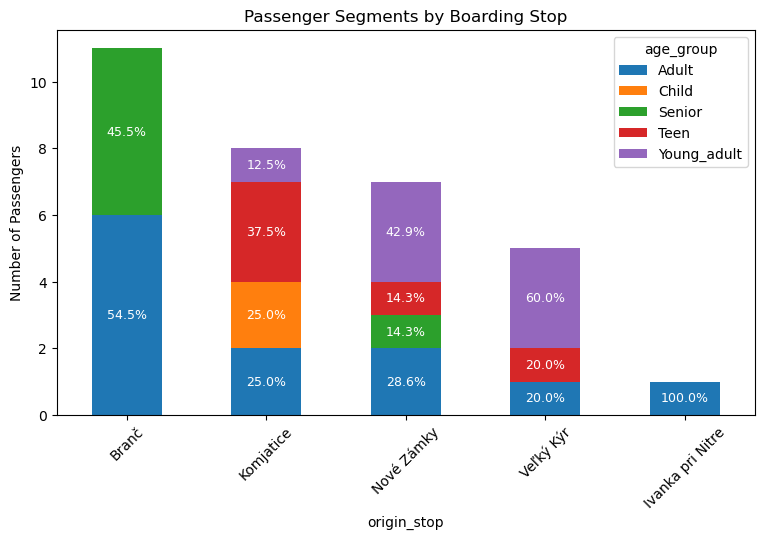

In [14]:
pivot_clean = pivot.drop(index="All", columns="All")
pivot_sorted = pivot_clean.loc[pivot_clean.sum(axis=1).sort_values(ascending=False).index]
ax = pivot_sorted.plot(kind="bar", stacked=True, figsize=(9,5))
plt.title("Passenger Segments by Boarding Stop")
plt.xticks(rotation=45)
plt.ylabel("Number of Passengers")

# Add percentages inside each bar
for j, row in enumerate(pivot_sorted.itertuples(index=False)):
    total = sum(row)
    cum_height = 0
    for i, val in enumerate(row):
        if val > 0:
            ax.text(x=j, y=cum_height + val/2, s=f'{val/total*100:.1f}%',
                    ha='center', va='center', color='white', fontsize=9)
            cum_height += val
plt.show()

Branč is the most frequented stop (11 passengers) and from the visualization it is clear that it is dominant for the Adult and Senior segments. Komjatice and Nové Zámky are, on the contrary, key for the young population, with a high representation of Teen and Young_adult. These stops are thus demographically non-homogeneous.

Looking at student status, we see:

In [15]:
pivot_student = pd.pivot_table(
    df,index="origin_stop", columns="is_student", values="minutes_on_bus", aggfunc="count", margins=True).fillna(0)
pivot_student

is_student,False,True,All
origin_stop,,,
Branč,11.0,0.0,11
Ivanka pri Nitre,1.0,0.0,1
Komjatice,3.0,5.0,8
Nové Zámky,3.0,4.0,7
Veľký Kýr,2.0,3.0,5
All,20.0,12.0,32


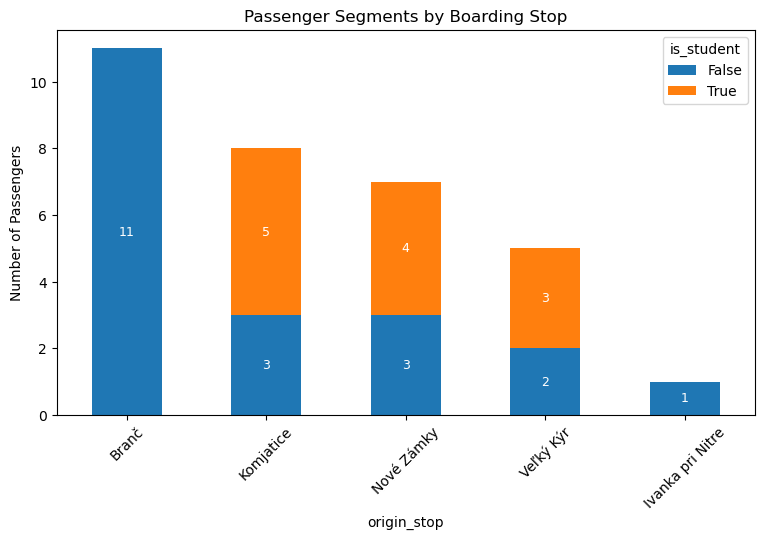

In [16]:
pivot_clean_student = pivot_student.drop(index="All", columns="All")
pivot_sorted_student = pivot_clean_student.loc[pivot_clean_student.sum(axis=1).sort_values(ascending=False).index]

ax = pivot_sorted_student.plot(kind="bar", stacked=True, figsize=(9,5))
plt.title("Passenger Segments by Boarding Stop")
plt.xticks(rotation=45)
plt.ylabel("Number of Passengers")
for j, row in enumerate(pivot_sorted_student.itertuples(index=False)):
    cum_height = 0
    for val in row:
        if val > 0:
            ax.text(x=j, y=cum_height + val/2, s=int(val), ha='center', va='center', color='white', fontsize=9)
            cum_height += val
plt.show()

Stops Branč and Ivanka pri Nitre are typically visited by non-students; Komjatice, Nové Zámky, and Veľký Kýr have a higher proportion of students.

Conclusion: The demographic structure of the stops is diverse and is not evenly distributed by student status. Some stops are more oriented towards the young population (students), others towards adults and seniors.

In the future analysis, we will verify the statistical dependency between `origin_stop` and `is_student`.

These findings about the demographic non-homogeneity of stops suggest that the age and student status of passengers are key factors in route and service planning. To better understand the behavior of different age groups during the ride, we will visually verify the relationship between age and digital engagement (`device_engagement`).

In [17]:
print("Contingency table: Average device_engagement by age_group")
pivot_engagement = pd.pivot_table(df, 
               index="age_group", 
               values="device_engagement", 
               aggfunc='mean').sort_values(by='device_engagement', ascending=False)
print(pivot_engagement.map(lambda x: f"{x:.2f}"))

Contingency table: Average device_engagement by age_group
            device_engagement
age_group                    
Teen                     4.20
Young_adult              3.29
Adult                    1.92
Child                    1.50
Senior                   1.00


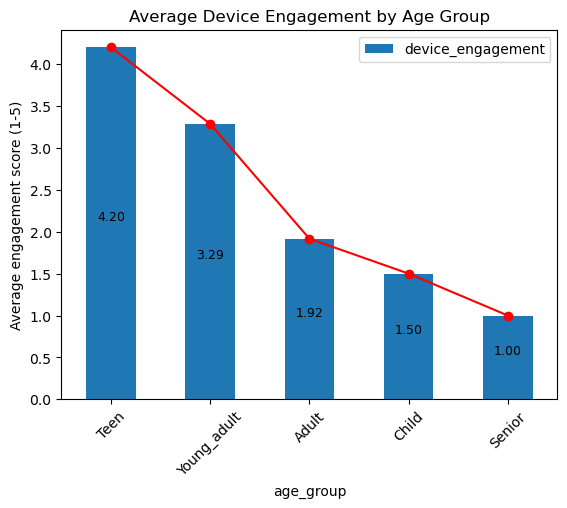

In [18]:
ax = pivot_engagement.plot.bar()
pivot_engagement['device_engagement'].plot.line(marker='o', color='red', ax=ax)
plt.title('Average Device Engagement by Age Group')
plt.ylabel('Average engagement score (1-5)')
plt.xticks(rotation=45)
for i, val in enumerate(pivot_engagement['device_engagement']):
    ax.text(i, val/2, f'{val:.2f}', ha='center', va='bottom', fontsize=9)
plt.show()

Conclusion: Age is a key factor for digital behavior during the ride.
- Engagement peaks at Teen (4.20), then declines.
- Child → Teen (+2.70): teenagers begin using phones intensively
- Young_adult → Adult (−1.37): the transition to working life reduces time spent on phones
- Senior (1.00): retirees almost never use phones during the ride

What's next: Verify the statistical significance of the correlation between age and `device_engagement` using Spearman's rho.

# **Analysis 1**
## **Inferential Analysis - Tests of Mean Values**

The goal of the following analysis is to determine which factors differentiate passengers and which variables are statistically related to each other.

We will verify the following areas:
- Does a discount affect trip length? `(minutes_on_bus × has_discount_ticket)`
- Do students carry different luggage weight than non-students? `(bag_weight_kg × is_student)`

**Test 1: `minutes_on_bus` vs. `has_discount_ticket`**

We verify whether different fare categories (defined by discount) lead to significantly different average times spent on the bus. Passengers with a discount (students, seniors) often use the bus as their primary mode of transport and may travel longer distances, while passengers without a discount mostly make shorter, occasional trips.

H0 (Null hypothesis): There is no statistically significant difference between the average time spent on the bus (`minutes_on_bus`) for passengers with a discount and passengers without a discount.

Parametric tests require normally distributed data. To use the parametric Two-Sample T-test, we must verify that the data is normally distributed (Shapiro-Wilk) and that the variances are homogeneous (Levene's test).

In [19]:
minutes_disc = df[df['has_discount_ticket'] == 'Yes']['minutes_on_bus']
minutes_no_disc = df[df['has_discount_ticket'] == 'No']['minutes_on_bus']

print("--- Normality Check ---")
print(f"Shapiro-Wilk p for Discount=Yes: {shapiro(minutes_disc).pvalue}")
print(f"Shapiro-Wilk p for Discount=No: {shapiro(minutes_no_disc).pvalue}")

--- Normality Check ---
Shapiro-Wilk p for Discount=Yes: 0.07025675782226651
Shapiro-Wilk p for Discount=No: 0.21777204057920418


Both p-values for Shapiro-Wilk are > 0.05 (0.0703 and 0.2178), so we do not reject H0 about normality. Levene's test (H0: Variances are equal) will determine which version of the T-test we use.

In [20]:
print(f"Levene's p-value: {levene(minutes_disc, minutes_no_disc).pvalue}")

Levene's p-value: 0.36727727593041604


The p-value for Levene's test (0.3673) is also > 0.05, which means the variances are homogeneous (equal), so we use the parametric Two-Sample T-test with pooled variance (`equal_var=True`).

In [21]:
t_stat, p_value = ttest_ind(minutes_disc, minutes_no_disc, equal_var=True)
print(f"T-Test p-value: {p_value}")

T-Test p-value: 0.09193236964216682


Conclusion: The calculated p-value > 0.05. Therefore, we do not reject the null hypothesis (H0). No statistically significant difference between the average time spent on the bus for passengers with and without a discount was found.

**Test 2: `bag_weight_kg` vs. `is_student`**

We tested whether students (defined using the `is_student` variable) carry a statistically significantly different luggage weight than non-students.

H0: There is no statistically significant difference in the median `bag_weight_kg` between the group `is_student` (True) and `is_student` (False).

In [22]:
bag_student = df[df['is_student'] == True]['bag_weight_kg']
bag_non_student = df[df['is_student'] == False]['bag_weight_kg']

print("\n--- Normality Check for Bag Weight vs. Is Student ---")
print(f"Shapiro-Wilk p for Student=Yes: {shapiro(bag_student).pvalue}")
print(f"Shapiro-Wilk p for Student=No: {shapiro(bag_non_student).pvalue}")


--- Normality Check for Bag Weight vs. Is Student ---
Shapiro-Wilk p for Student=Yes: 0.0561771261077463
Shapiro-Wilk p for Student=No: 0.003767928810745321


Normality for the non-student group was rejected (p=0.0038 < 0.05).

Since both groups must be normally distributed for the parametric t-test, the condition is not met. Therefore, we use the non-parametric alternative, the Mann-Whitney U test, which compares medians between two independent groups.

In [23]:
u_stat, p_value = mannwhitneyu(bag_student, bag_non_student, alternative='two-sided')
print(f"Mann-Whitney U p-value: {p_value}")

Mann-Whitney U p-value: 0.43513640642211593


Conclusion: The p-value is significantly higher than the significance level of 0.05, so we do not reject the null hypothesis. 
This means that no statistically significant difference in the median luggage weight between students and non-students was found.

Although in the exploratory analysis a visually observable difference was present between the groups (in the boxplot), the statistical test confirms that this difference is not large enough to be considered significant.

# **Analysis 2**
## **Inferential Analysis - Correlation Analysis**

The passenger dataset includes several important variables that may influence passenger behavior during a bus ride. We focus particularly on three areas:
- The relationship between age group and the rate of mobile device usage (device_engagement)
- The relationship between distance travelled and luggage weight
- The relationship between boarding stop and whether the passenger is a student

The goal is to identify which factors have a statistically significant effect and to find where significant differences between groups exist. The results can help us understand passenger behavior, audience segmentation, and possible directions for recommendations to the carrier.

**Test 3: device_engagement vs. age_group**

The dataset contains information about how intensively a passenger uses their device during the ride (scale 1–5).
We also have a breakdown into five age groups: Child, Teen, Young adult, Adult, Senior.

The goal is to determine whether a relationship exists between a passenger's age and the rate of mobile device usage during the ride.

H0: There is no statistically significant dependency between age group and the rate of mobile device usage during the ride.

First, we convert the age categories to ordinal values (1 = youngest → 5 = oldest), so we can quantitatively evaluate the order of age groups and use Spearman's correlation test.

In [24]:
age_map = {
    "Child": 1,
    "Teen": 2,
    "Young_adult": 3,
    "Adult": 4,
    "Senior": 5
}

df["age_group_num"] = df["age_group"].map(age_map)

Since both variables are ordinal, we use Spearman's correlation, which does not require normality or equal spacing between categories.

In [25]:
corr, p = spearmanr(df["age_group_num"], df["device_engagement"])

print("Spearman rho:", corr)
print("p-value:", p)

Spearman rho: -0.619504358103859
p-value: 0.0001563196139892391


The Spearman correlation between `age_group` and `device_engagement` is negative and statistically significant. We reject H0 (p < 0.05).
Higher age is associated with lower mobile device usage, however this relationship is not linear.

The highest device engagement is shown by Teen and Young adult, while Child have relatively low values and Seniors the lowest of all.

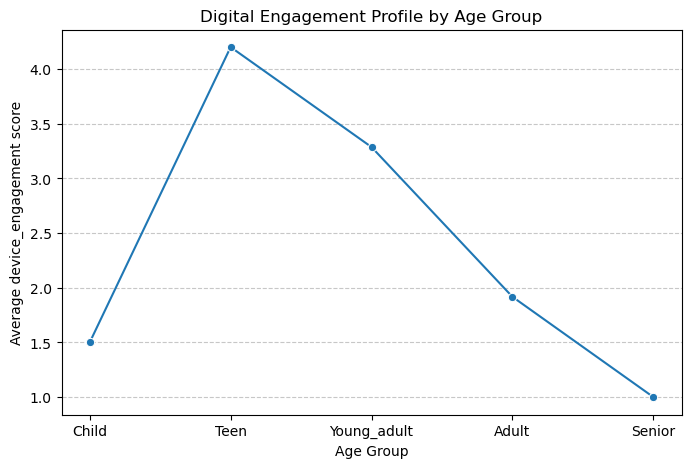

In [26]:
mean_engagement = df.groupby('age_group_num')['device_engagement'].mean().reset_index()

age_labels = {v: k for k, v in age_map.items()}

plt.figure(figsize=(8, 5))
sns.lineplot(data=mean_engagement, x='age_group_num', y='device_engagement', marker='o')
plt.title('Digital Engagement Profile by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Average device_engagement score')
plt.xticks(ticks=mean_engagement['age_group_num'], labels=[age_labels[i] for i in mean_engagement['age_group_num']])
plt.grid(True, axis='y', linestyle='--', alpha=0.7)
plt.show()

<Figure size 800x500 with 0 Axes>

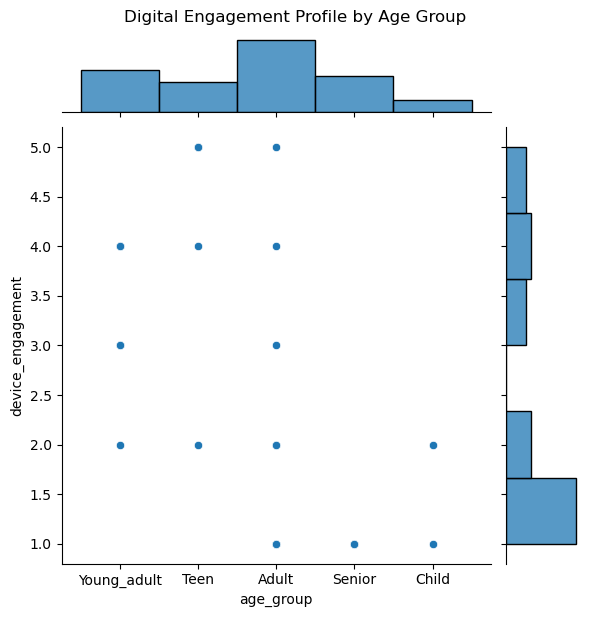

In [27]:
plt.figure(figsize=(8, 5))
sns.jointplot(data=df, x="age_group", y="device_engagement")
plt.suptitle('Digital Engagement Profile by Age Group', y=1.02)
plt.show()

The graph visually confirms the negative trend — Teen and Young_adult show the highest rate of engagement, while Seniors almost never use their phone during the ride.

**Test 4: `bag_weight_kg` vs. `travelled_distance_km`**

We test whether longer trips correlate with an increased need for luggage, which may be necessary for longer commutes or travel.

The earlier Shapiro-Wilk test for `bag_weight_kg` indicated a non-normal distribution, so we use Spearman's correlation — a non-parametric alternative to Pearson's correlation.

H0: There is no statistically significant dependency between the variables `bag_weight_kg` and `travelled_distance_km`.

In [28]:
corr, p = spearmanr(df['travelled_distance_km'], df['bag_weight_kg'])

print("Spearman rho:", corr)
print("p-value:", p)

Spearman rho: -0.009401124905583196
p-value: 0.9592729491925036


Spearman's correlation coefficient reached a value of ρ = −0.0094, which is a practically zero correlation. The p-value of the test (p = 0.9593) is significantly higher than the significance level of 0.05, so we do not reject the null hypothesis.

<Figure size 800x500 with 0 Axes>

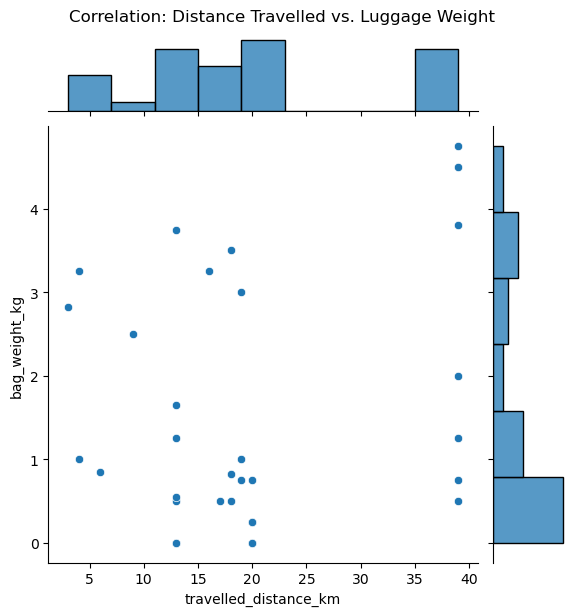

In [29]:
plt.figure(figsize=(8,5))
sns.jointplot(data=df, x="travelled_distance_km", y="bag_weight_kg")
plt.suptitle('Correlation: Distance Travelled vs. Luggage Weight', y=1.02)
plt.show()

Conclusion: There is no statistically significant relationship between trip length (`minutes_on_bus`) and luggage weight (`bag_weight_kg`). In practice, this means that passengers do not systematically carry heavier or lighter luggage depending on how long they travel by bus.

**Test 5: Contingency  `origin_stop` vs. `is_student`**

The goal is to determine whether the boarding stop is related to whether a passenger is a student. Both variables are categorical (nominal and binary), so the Chi-square test of independence is the appropriate tool.

H0: There is no statistically significant dependency between the boarding stop (`origin_stop`) and the passenger's status (`is_student`).

We create a contingency table showing the distribution of students and non-students at individual stops:

In [47]:
contingency = pd.crosstab(df['origin_stop'], df['is_student'])
print(contingency)

is_student        False  True 
origin_stop                   
Branč                11      0
Ivanka pri Nitre      1      0
Komjatice             3      5
Nové Zámky            3      4
Veľký Kýr             2      3


From the contingency table we can see a significant concentration of non-students at the Branč stop, where not a single student was recorded (11 × False, 0 × True). At the other stops non-students also prevail, but Komjatice, Nové Zámky, and Veľký Kýr show a higher proportion of students.

These differences in representation suggest a possible relationship between the boarding stop and whether the passenger is a student. We therefore also perform a formal Chi-square test of independence.

In [49]:
chi2, p, dof, expected = chi2_contingency(contingency)

print("Chi2:", chi2)
print("p-value:", p)

Chi2: 11.565714285714284
p-hodnota: 0.020890542755210163


Conclusion: The p-value of the Chi-square test is 0.0209, which is less than the chosen significance level of 0.05 — we reject the null hypothesis of independence. There is a statistically significant dependency between the boarding stop and student status.

The results show that students are not evenly distributed among the stops:
- Nové Zámky and Komjatice have a relatively high proportion of students,
- Veľký Kýr also has an increased representation,
- Branč and Ivanka pri Nitre capture almost no students.

The analysis thus confirms that individual stops have specific demographic profiles, which may be important for capacity planning, route scheduling, and targeted communication by the carrier.

# **Conclusion**

In this analysis, we verified several hypotheses regarding passenger behavior and demographics. The results showed that some relationships are statistically significant, while others were not confirmed. The key findings that can help the carrier in decision-making are as follows:

1. Digital Divide (Test 3): A strong and statistically significant negative relationship exists between a passenger's age and their rate of mobile device usage during the ride (ρ = −0.6195, p = 0.0002). This means that younger passengers (Teen, Young_adult) are significantly more active in phone usage. Older passengers (especially Seniors) show minimal digital activity.

Impact for the carrier: Digital channels, mobile applications, and online communication will be most effective for younger passengers. For older passengers, "traditional" forms of information (announcements in the bus, paper notices) should be retained.
  
2. Geographic Differences Between Stops (Test 5): Contingency analysis confirmed that individual boarding stops do not have the same demographic composition (p = 0.0456). Some stops are typically "student" stops, while others are predominantly for non-students:
- Branč – almost exclusively non-students
- Nové Zámky and Veľký Kýr – high proportion of students
- Komjatice – mixed, but students are more prominent

Impact for the carrier: This enables targeted marketing planning, capacity optimization, or service adjustment based on the type of passengers at individual stops.


3. Logistical Factors Were Not Confirmed (Tests 1, 2, and 4):
- Trip length and luggage weight are not related at all (ρ ≈ 0, p = 0.9593).
- Luggage weight of students and non-students does not differ statistically (p = 0.4351).
- No difference in time spent on the bus was demonstrated based on whether a passenger has or does not have a discounted ticket (p = 0.0919). Logistical relationships that appeared possible in the exploratory analysis were not confirmed. It appears that factors such as luggage or trip length behave independently of demographic characteristics.

  
The analysis could be extended by:
1. Comparison of specific extreme stops — Since the contingency analysis showed significant demographic differences between stops (e.g. Nové Zámky vs. Branč), it would be interesting to compare these two groups also from the perspective of metric variables such as `minutes_on_bus`. Such a targeted comparison could reveal whether the typical trip length differs between typically "student" and "non-student" stops. A Mann-Whitney U test or t-test (depending on whether normality conditions are met) could be used.

2. Regression analysis — So far we have examined relationships mostly in pairs of variables, but a regression model would allow us to determine which factors truly have the greatest influence on variables such as digital engagement (`device_engagement`) and trip length (`minutes_on_bus`). The model could account for age, stop, discount, student status, or variable interactions. This would provide a more comprehensive view of passenger behavior.

3. Comparison by season or day — If data from different time periods were available, it would be possible to verify whether student behavior and travel habits are stable over time.